## Full Shapefile Code

## 1. Imports and Paths

In [1]:
# install relevant packages
#!pip install geopandas 
#!pip install xarray netcdf4
import os
import geopandas as gpd
import pandas as pd
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# TASK 1: RETRIEVE SHAPEFILES
# path to directory containing shpfiles
shp_dir = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/" 

# path to SMAP soil moisture raster
raster_path = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_composite/2015_1_composite_weighted.nc"

## 2. Load NetCDF (SMAP)

In [2]:
# open SMAP GeoTIFF as an xarray DataArray
# ds = rioxarray.open_rasterio(raster_path, masked=True) # helps reduce memory usage

'''
Replaced the ds line of code with open_dataset
NetCDF files not read correctly with open_rasterio?
NetCDF files contain multiple variables and dimensions 
so they are not inherently "raster-like" until you select a var
'''

ds = xr.open_dataset(raster_path)
ds = ds[list(ds.data_vars)[0]] # selects the main variable (soil moisture) from the NetCDF file

ds = ds.rio.write_crs("EPSG:6933") # assigns CRS since NetCDF often doesn't store it in a way rioxarray reads

# print raster coordinate reference system to confirm projection
print(ds.rio.crs)

EPSG:6933


## 3. Loop Through Shapefiles (Setup Only)

In [ ]:
# loop through all folders inside shapefile directory
for folder in os.listdir(shp_dir):
    # create full path to each folder
    folder_path = os.path.join(shp_dir, folder)
    # check if item is in directory
    if os.path.isdir(folder_path):
        # construct path to shapefile
        shp_file = os.path.join(folder_path, f"{folder}.shp")
        # confirm that shapefile exists
        if os.path.exists(shp_file):
            print(f"Processing shapefile: {shp_file}")
            # read shapefile into a GeoDataFrame
            shp = gpd.read_file(shp_file)

Processing shapefile: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3629001/3629001.shp
Processing shapefile: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3667400/3667400.shp
Processing shapefile: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3666200/3666200.shp
Processing shapefile: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3275270/3275270.shp
Processing shapefile: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3268270/3268270.shp
Processing shapefile: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3458040/3458040.shp
Processing shapefile: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3514010/3514010.shp
Processing shapefile: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3652039/3652039.shp
Processing shapefile: /global/sc

## 4. Polygon Cleaning and Filtering

In [13]:
            '''
            NOTES: need to add logic to check polygons
            '''

            # remove empty or invalid geometries
            shp = shp[shp.geometry.notnull()]
            shp = shp[shp.is_valid]

            # function to count number of vertices in polygon
            def count_vertices(geom):
                if geom.geom_type == "Polygon":
                    return len(geom.exterior.coords)
                elif geom.geom_type == "MultiPolygon":
                    return max(len(p.exterior.coords) for p in geom.geoms)
                else:
                    return 0
            # apply vertex counting
            shp["n_vertices"] = shp.geometry.apply(count_vertices)

            # store original number of polygons before filtering
            orginal_count = len(shp)

            # filter out simple squares/rectangles (typicall 5 vertices (first = last))
            shp = shp[shp["n_vertices"] > 5]

            # count how many polygons were removed
            filtered_count = orginal_count - len(shp)

            # print how many polygons remain
            print(f"Remaining polygons after filtering: {len(shp)}")

            # print how many polygons were ignored
            print(f"Ignored {filtered_count} square/rectangular polygons")

            # skip if no valid polygons remain
            if shp.empty:
                print("No valid (non-rectangular) polygons found, skipping...")
                continue

Remaining polygons after filtering: 1
Ignored 0 square/rectangular polygons


SyntaxError: 'continue' not properly in loop (3761988939.py, line 38)

## 5. Reproject to EASE Grid

In [7]:
            # TASK 2: CONVERT COORDINATES TO EASE GRID

            # convert shapefile coordinates from lat/lon to EASE grid projection
            shp_ease = shp.to_crs("EPSG:6933")

            # print CRS check
            print("Shapefile CRS: ", shp.crs)
            print("EASE CRS: ", shp_ease.crs)

Shapefile CRS:  EPSG:4326
EASE CRS:  EPSG:6933


## 6. Clip Raster

In [7]:
            # TASK 3: CROP SMAP DATA USING SHAPEFILE

            # clip SMAP raster to polygon boundary of shapefile
            clipped = ds.rio.clip(shp_ease.geometry, shp_ease.crs, from_disk=True) # from_disk=True avoids loading full dataset into memory

            # plot clipped raster
            clipped.squeeze().plot()
            plt.title(f"Cropped SMAP - {folder}")
            plt.show()

            # overlay shapefile boundary on raster
            fig, ax = plt.subplots()
            clipped.squeeze().plot(ax=ax)
            shp_ease.boundary.plot(ax=ax)
            plt.title(f"Overlay check - {folder}")
            plt.show()

            # print bounds check
            print("Shapefile bounds: ", shp_ease.total_bounds)
            print("Raster bounds: ", ds.rio.bounds())

NameError: name 'ds' is not defined

## 7. Statistics

In [ ]:
            '''
            NOTES: need to get mean and stand dev
            '''

            # compute mean soil moisture
            mean_sm = float(clipped.mean().values)

            # compute standrad deviation
            std_sm = float(clipped.std().values)

            # print mean and std
            print(f"Mean Soil Moisture: {mean_sm}")
            print(f"Standard Deviation: {std_sm}")

            # print min/max for sanity check
            print(f"Min: {float(clipped.min().values)}")
            print(f"Max: {float(clipped.max().values)}")

            # count valid pixels
            valid_pixels = int(clipped.count().values)
            print(f"Valid pixels: {valid_pixels}")

            # manual mean check
            vals = clipped.values.flatten()
            vals = vals[~np.isnan(vals)]
            print("Manual mean: ", vals.mean())

## 8. Save Cropped Raster

In [ ]:
            # create filename for cropped raster
            output_name = f"{folder}_cropped.tif"

            # full output path for clipped raster
            output_path = os.path.join(shp_dir, output_name)

            # save cropped raster as a new GeoTIFF
            #clipped.rio.to_raster(output_path)

            print(f"Cropped raster saved to: {output_path}")

## 9. Create CSV for Each Month

In [ ]:
# create a CSV for each folder/month
csv_output_dir = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_csvs/"

if not os.path.exists(csv_output_dir):
    os.makedirs(csv_output_dir)

# loop again through folders to save CSV
for folder in os.listdir(shp_dir):
    folder_path = os.path.join(shp_dir, folder)
    if os.path.isdir(folder_path):
        shp_file = os.path.join(folder_path, f"{folder}.shp")
        if os.path.exists(shp_file):
            shp = gpd.read_file(shp_file)
            shp = shp[shp.geometry.notnull()]
            shp = shp[shp.is_valid]

            # vertex filtering
            shp["n_vertices"] = shp.geometry.apply(count_vertices)
            shp = shp[shp["n_vertices"] > 5]
            if shp.empty:
                continue

            # reproject
            shp_ease = shp.to_crs("EPSG:6933")

            # clip raster
            clipped = ds.rio.clip(shp_ease.geometry, shp_ease.crs, from_disk=True)

            # prepare dataframe for CSV
            vals = clipped.values.flatten()
            vals = vals[~np.isnan(vals)]
            df = pd.DataFrame({"soil_moisture": vals})

            # save CSV
            csv_path = os.path.join(csv_output_dir, f"{folder}_soil_moisture.csv")
            df.to_csv(csv_path, index=False)
            print(f"CSV saved: {csv_path}")

## Massive Code

In [16]:
# install relevant packages
!pip install geopandas 
!pip install xarray netcdf4
import os
import geopandas as gpd
import pandas as pd
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# TASK 1: RETRIEVE SHAPEFILES
# path to directory containing shpfiles
shp_dir = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/" 

# path to SMAP soil moisture raster
raster_path = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_composite/2015_1_composite_weighted.nc"

# open SMAP GeoTIFF as an xarray DataArray
# ds = rioxarray.open_rasterio(raster_path, masked=True) # helps reduce memory usage

'''
Replaced the ds line of code with open_dataset
NetCDF files not read correctly with open_rasterio?
NetCDF files contain multiple variables and dimensions 
so they are not inherently "raster-like" until you select a var
'''

ds = xr.open_dataset(raster_path)
ds = ds[list(ds.data_vars)[0]] # selects the main variable (soil moisture) from the NetCDF file

ds = ds.rio.write_crs("EPSG:6933") # assigns CRS since NetCDF often doesn't store it in a way rioxarray reads

# print raster coordinate reference system to confirm projection
print(ds.rio.crs)

# loop through all folders inside shapefile directory
for folder in os.listdir(shp_dir):
    # create full path to each folder
    folder_path = os.path.join(shp_dir, folder)
    # check if item is in directory
    if os.path.isdir(folder_path):
        # construct path to shapefile
        shp_file = os.path.join(folder_path, f"{folder}.shp")
        # confirm that shapefile exists
        if os.path.exists(shp_file):
            print(f"Processing shapefile: {shp_file}")
            # read shapefile into a GeoDataFrame
            shp = gpd.read_file(shp_file)
            
            '''
            NOTES: need to add logic to check polygons
            '''

            # remove empty or invalid geometries
            shp = shp[shp.geometry.notnull()]
            shp = shp[shp.is_valid]

            # function to count number of vertices in polygon
            def count_vertices(geom):
                if geom.geom_type == "Polygon":
                    return len(geom.exterior.coords)
                elif geom.geom_type == "MultiPolygon":
                    return max(len(p.exterior.coords) for p in geom.geoms)
                else:
                    return 0
            # apply vertex counting
            shp["n_vertices"] = shp.geometry.apply(count_vertices)

            # store original number of polygons before filtering
            orginal_count = len(shp)

            # filter out simple squares/rectangles (typicall 5 vertices (first = last))
            shp = shp[shp["n_vertices"] > 5]

            # count how many polygons were removed
            filtered_count = orginal_count - len(shp)

            # print how many polygons remain
            print(f"Remaining polygons after filtering: {len(shp)}")

            # print how many polygons were ignored
            print(f"Ignored {filtered_count} square/rectangular polygons")

            # skip if no valid polygons remain
            if shp.empty:
                print("No valid (non-rectangular) polygons found, skipping...")
                continue
            
            # TASK 2: CONVERT COORDINATES TO EASE GRID

            # convert shapefile coordinates from lat/lon to EASE grid projection
            shp_ease = shp.to_crs("EPSG:6933")

            # print CRS check
            print("Shapefile CRS: ", shp.crs)
            print("EASE CRS: ", shp_ease.crs)

            # TASK 3: CROP SMAP DATA USING SHAPEFILE

            # clip SMAP raster to polygon boundary of shapefile
            clipped = ds.rio.clip(shp_ease.geometry, shp_ease.crs, from_disk=True) # from_disk=True avoids loading full dataset into memory

            # plot clipped raster
            clipped.squeeze().plot()
            plt.title(f"Cropped SMAP - {folder}")
            plt.show()

            # overlay shapefile boundary on raster
            fig, ax = plt.subplots()
            clipped.squeeze().plot(ax=ax)
            shp_ease.boundary.plot(ax=ax)
            plt.title(f"Overlay check - {folder}")
            plt.show()

            # print bounds check
            print("Shapefile bounds: ", shp_ease.total_bounds)
            print("Raster bounds: ", ds.rio.bounds())

            '''
            NOTES: need to get mean and stand dev
            '''

            # compute mean soil moisture
            mean_sm = float(clipped.mean().values)

            # compute standrad deviation
            std_sm = float(clipped.std().values)

            # print mean and std
            print(f"Mean Soil Moisture: {mean_sm}")
            print(f"Standard Deviation: {std_sm}")

            # print min/max for sanity check
            print(f"Min: {float(clipped.min().values)}")
            print(f"Max: {float(clipped.max().values)}")

            # count valid pixels
            valid_pixels = int(clipped.count().values)
            print(f"Valid pixels: {valid_pixels}")

            # manual mean check
            vals = clipped.values.flatten()
            vals = vals[~np.isnan(vals)]
            print("Manual mean: ", vals.mean())

            # create filename for cropped raster
            output_name = f"{folder}_cropped.tif"

            # full output path for clipped raster
            output_path = os.path.join(shp_dir, output_name)

            # save cropped raster as a new GeoTIFF
            #clipped.rio.to_raster(output_path)

            print(f"Cropped raster saved to: {output_path}")

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
EPSG:6933
Processing shapefile: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3629001/3629001.shp
Remaining polygons after filtering: 2
Ignored 0 square/rectangular polygons
Shapefile CRS:  EPSG:4326
EASE CRS:  EPSG:6933


MissingSpatialDimensionError: y dimension not found. 'rio.set_spatial_dims()' or using 'rename()' to change the dimension name to 'y' can address this. Data variable: spatial_ref

## SLS Code

In [ ]:
# Initializing shp and ds list
import os
import gc
# List of shpfiles
shp_dir = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/" 
shp_list = []
for folder in os.listdir(shp_dir):
    # create full path to each folder
    folder_path = os.path.join(shp_dir, folder)
    # check if item is in directory
    if os.path.isdir(folder_path):
        # construct path to shapefile
        shp_file = os.path.join(folder_path, f"{folder}.shp")
        shp_list.append(shp_file)

# list of Ds
ds_list = []
for file in os.listdir('/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_composite/'):
    ds_list.append(file)
# 2018 only
ds_list = sorted(
    [
        f for f in ds_list
        if (2018, 8) <= tuple(map(int, f.split("_")[:2])) <= (2018, 11)
    ],
    key=lambda x: (int(x.split("_")[0]), int(x.split("_")[1]))
)

# Meethods
def count_vertices(geom):
    if geom.geom_type == "Polygon":
        return len(geom.exterior.coords)
    elif geom.geom_type == "MultiPolygon":
        return max(len(p.exterior.coords) for p in geom.geoms)
    else:
        return 0

def fetch_SHP(shp_file):
    print(f"Processing station: {shp_file[-11:-4]}")
    # read shapefile into a GeoDataFrame
    shp = gpd.read_file(shp_file)
    
    # remove empty or invalid geometries
    shp = shp[shp.geometry.notnull()]
    shp = shp[shp.is_valid]
    
    # apply vertex counting
    shp["n_vertices"] = shp.geometry.apply(count_vertices)
    orginal_count = len(shp)
    # filter out simple squares/rectangles (typicall 5 vertices (first = last))
    shp = shp[shp["n_vertices"] > 5]
    filtered_count = orginal_count - len(shp)
    #print(f"Remaining polygons after filtering: {len(shp)}")
    
    if shp.empty:
        print("No valid (non-rectangular) polygons found, skipping...")
        return None
        #continue
    
    # 2 : ease grid
    shp_ease = shp.to_crs("EPSG:6933")
    #print("Shapefile CRS: ", shp.crs)
    #print("EASE CRS: ", shp_ease.crs)
    return(shp_ease)

def initialize_DS(raster_path):
    ds = xr.open_dataset(raster_path)
    ds = ds['composite'] # selects the main variable (soil moisture) from the NetCDF file
    ds = ds.rio.write_crs("EPSG:6933") # assigns CRS since NetCDF often doesn't store it in a way rioxarray reads
    return ds

def clip_SM(shp_file, ds, plot = True):
    print('Clipping SM')
    
    # get shpfile
    shp_ease = fetch_SHP(shp_file)
    if shp_ease is None:
        return None
    
    # clip with shpfile
    # Get bounding box of shapefile
    minx, miny, maxx, maxy = shp_ease.total_bounds
    
    # Quick rectangular crop (FAST)
    ds_subset = ds.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
    clipped = ds_subset.rio.clip(shp_ease.geometry, shp_ease.crs, from_disk=True)

    # plot (OPTIONAL)
    if plot == True:
        clipped.squeeze().plot()
        plt.title(f"Cropped SMAP - {shp_file}")
        plt.show()
        
        # overlay shapefile boundary on raster
        fig, ax = plt.subplots()
        clipped.squeeze().plot(ax=ax)
        shp_ease.boundary.plot(ax=ax)
        plt.title(f"Overlay check - {shp_file}")
        plt.show()

    # Get stats------------------------------
    mean_sm = float(clipped.mean().values)
    std_sm = float(clipped.std().values)
    
    min_sm = float(clipped.min().values)
    max_sm = float(clipped.max().values)
    
    qs = clipped.quantile([0.25, 0.5, 0.75])
    p25_sm = float(qs.sel(quantile=0.25).values)
    median_sm = float(qs.sel(quantile=0.5).values)
    p75_sm = float(qs.sel(quantile=0.75).values)
    
    # count valid pixels
    valid_pixels = int(clipped.count().values)
    
    return (
        mean_sm, std_sm,
        min_sm, max_sm,
        median_sm, p25_sm, p75_sm,
        valid_pixels
    )

def init_total_csv(path):
    df = pd.read_csv(path)

    # Ensure consistent types
    df['Date'] = df['Date'].astype(str)
    df['GRDC_No'] = df['GRDC_No'].astype(int)

    # Ensure columns exist
    for c in ['mean_sm', 'std_sm', 'min_sm', 'max_sm',
          'median_sm', 'p25_sm', 'p75_sm', 'valid_pixels']:
        if c not in df.columns:
            df[c] = pd.NA

    return df

def update_total_csv(df, year_ds, month_ds, station_shp,
                     mean_sm, std_sm, min_sm, max_sm,
                     median_sm, p25_sm, p75_sm, valid_pixels):
    print('Updating csv...')
    date_str = f"{year_ds}-{month_ds:02d}"

    mask = (
        (df['GRDC_No'] == int(station_shp)) &
        (df['Date'] == date_str)
    )

    if not mask.any():
        print(f"No match for station={station_shp}, date={date_str}")
        return None

    df.loc[mask, [
            'mean_sm', 'std_sm', 'min_sm', 'max_sm',
            'median_sm', 'p25_sm', 'p75_sm', 'valid_pixels'
        ]] = [
            mean_sm, std_sm, min_sm, max_sm,
            median_sm, p25_sm, p75_sm, valid_pixels
        ]
    print('Done!')

def save_total_csv(df, path):
    df.to_csv(path, index=False)
    print('Saved csv')

# Inputs

#ds_OI = ds_list[10]
#shp_file = shp_list[23]
#-------------
csv_path = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/ALL_STATIONS_ALL_MONTHS_cp_sm_UVA.csv'
df = init_total_csv(csv_path)


# LOOP---------------------
import time
# 1. Initialize

for ds_OI in ds_list:
    year, month = ds_OI.split("_")[:2]
    year_ds = int(year)
    month_ds = int(month)
    raster_path = f"/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_composite/{year_ds}_{month_ds}_composite_weighted.nc"
    print(f'\n-----------------------\nPROCESSING {year_ds}, {month_ds}: {raster_path}')
    try:
        ds_temp = initialize_DS(raster_path)
    except Exception as e:
        print(f"Skipping {raster_path} (failed to open): {e}")
        continue

    # 2. Loop thru shpfile
    start = time.time()
    for shp_file in shp_list:
        try:
            print(' ')
            #Shpfile clipping
            station_shp = os.path.basename(shp_file).replace(".shp", "")
            start_shp = time.time()
            result = clip_SM(shp_file, ds_temp, False)
            if result is None:
                continue
            mean_sm, std_sm, min_sm, max_sm, median_sm, p25_sm, p75_sm, valid_pixels = result

            # 3. Update csv
            update_total_csv(
                df, year_ds, month_ds, station_shp,
                mean_sm, std_sm, min_sm, max_sm,
                median_sm, p25_sm, p75_sm, valid_pixels
            )
            del result
            gc.collect()
            end = time.time()
            print(f"Step time: {end - start_shp:.2f} seconds")
        except Exception as e:
            print(f" Failed for {shp_file}: {e}")
    save_total_csv(df, csv_path)
    
end_tot = time.time()
print(f"Total time: {end_tot - start:.2f} seconds")


-----------------------
PROCESSING 2018, 11: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_composite/2018_11_composite_weighted.nc
 
Clipping SM
Processing station: 3629001
Updating csv...
Done!
Step time: 0.91 seconds
 
Clipping SM
Processing station: 3667400
Updating csv...
Done!
Step time: 0.89 seconds
 
Clipping SM
Processing station: 3666200
Updating csv...
Done!
Step time: 1.02 seconds
 
Clipping SM
Processing station: 3275270
Updating csv...
Done!
Step time: 2.15 seconds
 
Clipping SM
Processing station: 3268270
Updating csv...
Done!
Step time: 0.73 seconds
 
Clipping SM
Processing station: 3458040
Updating csv...
No match for station=3458040, date=2018-11
Step time: 0.62 seconds
 
Clipping SM
Processing station: 3514010
Updating csv...
No match for station=3514010, date=2018-11
Step time: 0.96 seconds
 
Clipping SM
Processing station: 3652039
Updating csv...
Done!
Step time: 1.15 seconds
 
Clipping SM
Processing station: 415180

In [ ]:
ds_list


-----------------------
PROCESSING 2023, 10: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_composite/2023_10_composite_weighted.nc
 
Clipping SM
Processing station: 3629001


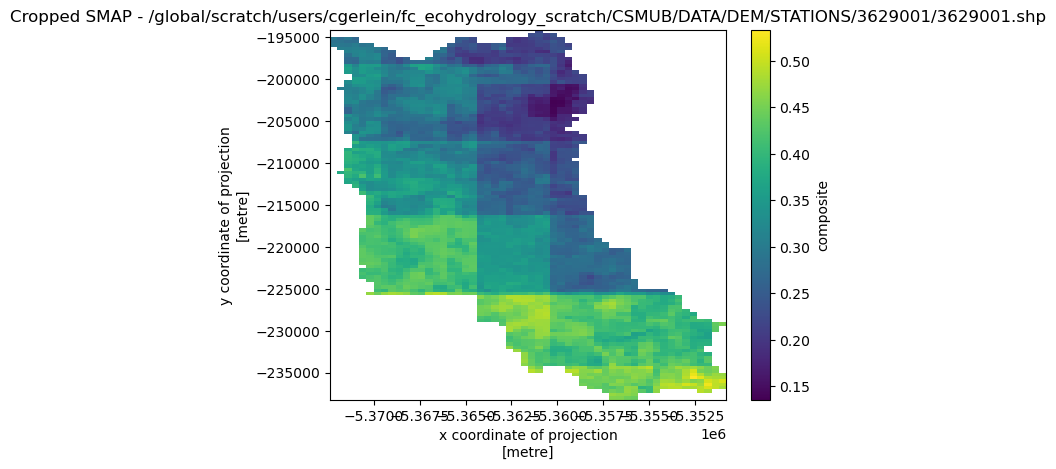

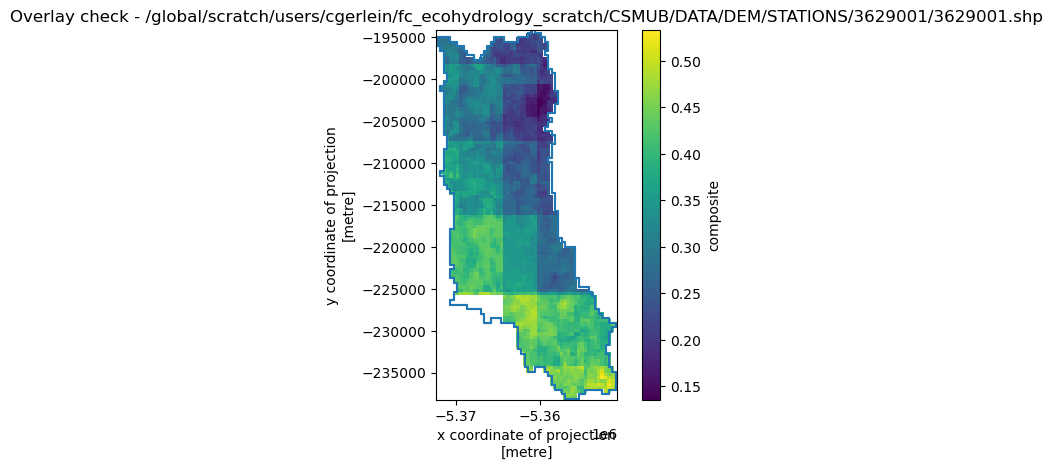

 Failed for /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3629001/3629001.shp: name 'df' is not defined

-----------------------
PROCESSING 2023, 11: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_composite/2023_11_composite_weighted.nc
 
Clipping SM
Processing station: 3629001


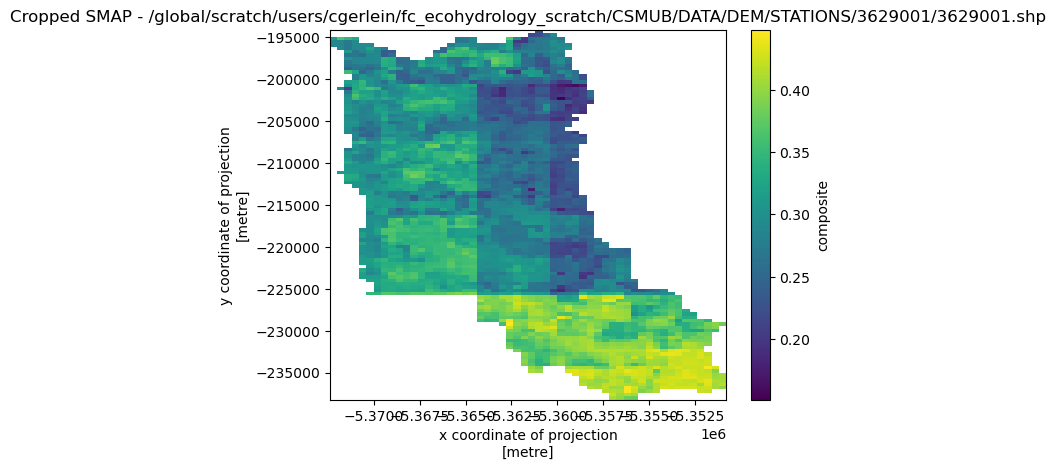

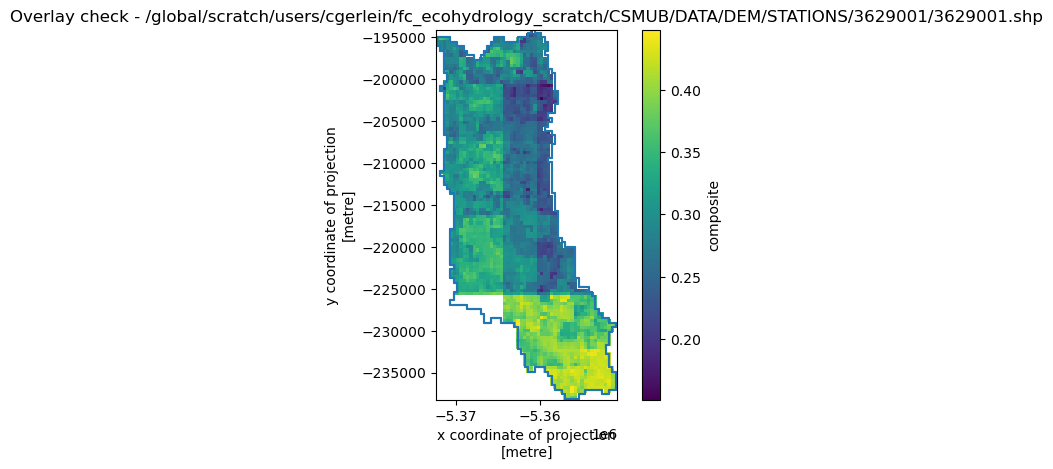

 Failed for /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3629001/3629001.shp: name 'df' is not defined
Total time: 1.13 seconds


In [9]:
# DEBUG
# Initializing shp and ds list
import os
import gc
# List of shpfiles
shp_dir = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/" 
shp_list = []
for folder in os.listdir(shp_dir):
    # create full path to each folder
    folder_path = os.path.join(shp_dir, folder)
    # check if item is in directory
    if os.path.isdir(folder_path):
        # construct path to shapefile
        shp_file = os.path.join(folder_path, f"{folder}.shp")
        shp_list.append(shp_file)

# list of Ds
ds_list = []
for file in os.listdir('/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_composite/'):
    ds_list.append(file)
# 2018 only
ds_list = sorted(
    [
        f for f in ds_list
        if (2023, 9) <= tuple(map(int, f.split("_")[:2])) <= (2024, 7)
    ],
    key=lambda x: (int(x.split("_")[0]), int(x.split("_")[1]))
)

# Meethods
def count_vertices(geom):
    if geom.geom_type == "Polygon":
        return len(geom.exterior.coords)
    elif geom.geom_type == "MultiPolygon":
        return max(len(p.exterior.coords) for p in geom.geoms)
    else:
        return 0

def fetch_SHP(shp_file):
    print(f"Processing station: {shp_file[-11:-4]}")
    # read shapefile into a GeoDataFrame
    shp = gpd.read_file(shp_file)
    
    # remove empty or invalid geometries
    shp = shp[shp.geometry.notnull()]
    shp = shp[shp.is_valid]
    
    # apply vertex counting
    shp["n_vertices"] = shp.geometry.apply(count_vertices)
    orginal_count = len(shp)
    # filter out simple squares/rectangles (typicall 5 vertices (first = last))
    shp = shp[shp["n_vertices"] > 5]
    filtered_count = orginal_count - len(shp)
    #print(f"Remaining polygons after filtering: {len(shp)}")
    
    if shp.empty:
        print("No valid (non-rectangular) polygons found, skipping...")
        return None
        #continue
    
    # 2 : ease grid
    shp_ease = shp.to_crs("EPSG:6933")
    #print("Shapefile CRS: ", shp.crs)
    #print("EASE CRS: ", shp_ease.crs)
    return(shp_ease)

def initialize_DS(raster_path):
    ds = xr.open_dataset(raster_path)
    ds = ds['composite'] # selects the main variable (soil moisture) from the NetCDF file
    ds = ds.rio.write_crs("EPSG:6933") # assigns CRS since NetCDF often doesn't store it in a way rioxarray reads
    return ds

def clip_SM(shp_file, ds, plot = True):
    print('Clipping SM')
    
    # get shpfile
    shp_ease = fetch_SHP(shp_file)
    if shp_ease is None:
        return None
    
    # clip with shpfile
    # Get bounding box of shapefile
    minx, miny, maxx, maxy = shp_ease.total_bounds
    
    # Quick rectangular crop (FAST)
    ds_subset = ds.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
    clipped = ds_subset.rio.clip(shp_ease.geometry, shp_ease.crs, from_disk=True)

    # plot (OPTIONAL)
    if plot == True:
        clipped.squeeze().plot()
        plt.title(f"Cropped SMAP - {shp_file}")
        plt.show()
        
        # overlay shapefile boundary on raster
        fig, ax = plt.subplots()
        clipped.squeeze().plot(ax=ax)
        shp_ease.boundary.plot(ax=ax)
        plt.title(f"Overlay check - {shp_file}")
        plt.show()

    # Get stats------------------------------
    mean_sm = float(clipped.mean().values)
    std_sm = float(clipped.std().values)
    
    min_sm = float(clipped.min().values)
    max_sm = float(clipped.max().values)
    
    qs = clipped.quantile([0.25, 0.5, 0.75])
    p25_sm = float(qs.sel(quantile=0.25).values)
    median_sm = float(qs.sel(quantile=0.5).values)
    p75_sm = float(qs.sel(quantile=0.75).values)
    
    # count valid pixels
    valid_pixels = int(clipped.count().values)
    
    return (
        mean_sm, std_sm,
        min_sm, max_sm,
        median_sm, p25_sm, p75_sm,
        valid_pixels
    )

def init_total_csv(path):
    df = pd.read_csv(path)

    # Ensure consistent types
    df['Date'] = df['Date'].astype(str)
    df['GRDC_No'] = df['GRDC_No'].astype(int)

    # Ensure columns exist
    for c in ['mean_sm', 'std_sm', 'min_sm', 'max_sm',
          'median_sm', 'p25_sm', 'p75_sm', 'valid_pixels']:
        if c not in df.columns:
            df[c] = pd.NA

    return df

def update_total_csv(df, year_ds, month_ds, station_shp,
                     mean_sm, std_sm, min_sm, max_sm,
                     median_sm, p25_sm, p75_sm, valid_pixels):
    print('Updating csv...')
    date_str = f"{year_ds}-{month_ds:02d}"

    mask = (
        (df['GRDC_No'] == int(station_shp)) &
        (df['Date'] == date_str)
    )

    if not mask.any():
        print(f"No match for station={station_shp}, date={date_str}")
        return None

    df.loc[mask, [
            'mean_sm', 'std_sm', 'min_sm', 'max_sm',
            'median_sm', 'p25_sm', 'p75_sm', 'valid_pixels'
        ]] = [
            mean_sm, std_sm, min_sm, max_sm,
            median_sm, p25_sm, p75_sm, valid_pixels
        ]
    print('Done!')

def save_total_csv(df, path):
    df.to_csv(path, index=False)
    print('Saved csv')

# Inputs

#ds_OI = ds_list[10]
#shp_file = shp_list[23]
#-------------
csv_path = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/ALL_STATIONS_ALL_MONTHS_cp_sm_UVA.csv'
#df = init_total_csv(csv_path)


# LOOP---------------------
import time
# 1. Initialize

for ds_OI in ds_list[1:3]:
    year, month = ds_OI.split("_")[:2]
    year_ds = int(year)
    month_ds = int(month)
    raster_path = f"/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_composite/{year_ds}_{month_ds}_composite_weighted.nc"
    print(f'\n-----------------------\nPROCESSING {year_ds}, {month_ds}: {raster_path}')
    try:
        ds_temp = initialize_DS(raster_path)
    except Exception as e:
        print(f"Skipping {raster_path} (failed to open): {e}")
        continue

    # 2. Loop thru shpfile
    start = time.time()
    for shp_file in shp_list[0:1]:
        try:
            print(' ')
            #Shpfile clipping
            station_shp = os.path.basename(shp_file).replace(".shp", "")
            start_shp = time.time()
            result = clip_SM(shp_file, ds_temp, True)
            if result is None:
                continue
            mean_sm, std_sm, min_sm, max_sm, median_sm, p25_sm, p75_sm, valid_pixels = result

            # 3. Update csv
            update_total_csv(
                df, year_ds, month_ds, station_shp,
                mean_sm, std_sm, min_sm, max_sm,
                median_sm, p25_sm, p75_sm, valid_pixels
            )
            del result
            gc.collect()
            end = time.time()
            print(f"Step time: {end - start_shp:.2f} seconds")
        except Exception as e:
            print(f" Failed for {shp_file}: {e}")
    #save_total_csv(df, csv_path)
    
end_tot = time.time()
print(f"Total time: {end_tot - start:.2f} seconds")

In [7]:
'2023_9_composite_weighted.nc'.split("_")[:2]

['2023', '9']

## DEBUGGING

In [32]:
# TASK 1: RETRIEVE SHAPEFILES
# path to directory containing shpfiles
shp_dir = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/" 

# path to SMAP soil moisture raster
raster_path = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_SOILMOISTURE_UVA/monthly_composite/2015_1_composite_weighted.nc"
ds = xr.open_dataset(raster_path)
ds = ds['composite'] # selects the main variable (soil moisture) from the NetCDF file
ds = ds.rio.write_crs("EPSG:6933") # assigns CRS since NetCDF often doesn't store it in a way rioxarray reads


In [33]:
list = []
for folder in os.listdir(shp_dir):
    # create full path to each folder
    folder_path = os.path.join(shp_dir, folder)
    # check if item is in directory
    if os.path.isdir(folder_path):
        # construct path to shapefile
        shp_file = os.path.join(folder_path, f"{folder}.shp")
        list.append(shp_file)
list

['/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3629001/3629001.shp',
 '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3667400/3667400.shp',
 '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3666200/3666200.shp',
 '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3275270/3275270.shp',
 '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3268270/3268270.shp',
 '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3458040/3458040.shp',
 '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3514010/3514010.shp',
 '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3652039/3652039.shp',
 '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/4151802/4151802.shp',
 '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/S

In [34]:
shp_file = list[23]
print(f"Processing shapefile: {shp_file}")
# read shapefile into a GeoDataFrame
shp = gpd.read_file(shp_file)

# remove empty or invalid geometries
shp = shp[shp.geometry.notnull()]
shp = shp[shp.is_valid]

def count_vertices(geom):
    if geom.geom_type == "Polygon":
        return len(geom.exterior.coords)
    elif geom.geom_type == "MultiPolygon":
        return max(len(p.exterior.coords) for p in geom.geoms)
    else:
        return 0
# apply vertex counting
shp["n_vertices"] = shp.geometry.apply(count_vertices)
orginal_count = len(shp)
# filter out simple squares/rectangles (typicall 5 vertices (first = last))
shp = shp[shp["n_vertices"] > 5]
filtered_count = orginal_count - len(shp)
print(f"Remaining polygons after filtering: {len(shp)}")

if shp.empty:
    print("No valid (non-rectangular) polygons found, skipping...")
    #continue


# 2 : ease grid
shp_ease = shp.to_crs("EPSG:6933")
print("Shapefile CRS: ", shp.crs)
print("EASE CRS: ", shp_ease.crs)
shp

Processing shapefile: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/4148300/4148300.shp
Remaining polygons after filtering: 2
Shapefile CRS:  EPSG:4326
EASE CRS:  EPSG:6933


,LABEL,geometry,n_vertices
0,1,"POLYGON ((-80.63333 36.67917, -80.625 36.67917...",1719
1,0,"POLYGON ((-80.63333 36.67917, -80.625 36.67917...",1719


In [35]:
clipped = ds.rio.clip(shp_ease.geometry, shp_ease.crs, from_disk=True) # from_disk=True avoids loading full dataset into memory

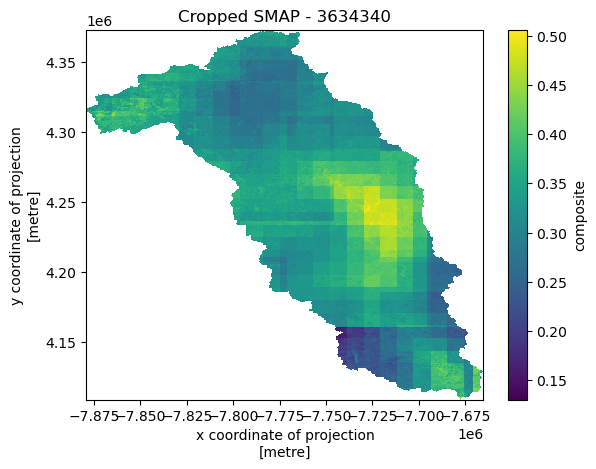

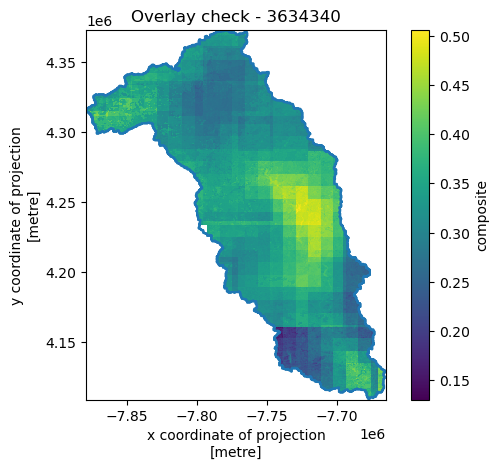

In [36]:
# plot clipped raster
clipped.squeeze().plot()
plt.title(f"Cropped SMAP - {folder}")
plt.show()

# overlay shapefile boundary on raster
fig, ax = plt.subplots()
clipped.squeeze().plot(ax=ax)
shp_ease.boundary.plot(ax=ax)
plt.title(f"Overlay check - {folder}")
plt.show()


In [37]:
# print bounds check
print("Shapefile bounds: ", shp_ease.total_bounds)
print("Raster bounds: ", ds.rio.bounds())

'''
NOTES: need to get mean and stand dev
'''

# compute mean soil moisture
mean_sm = float(clipped.mean().values)

# compute standrad deviation
std_sm = float(clipped.std().values)

# print mean and std
print(f"Mean Soil Moisture: {mean_sm}")
print(f"Standard Deviation: {std_sm}")

# print min/max for sanity check
print(f"Min: {float(clipped.min().values)}")
print(f"Max: {float(clipped.max().values)}")

# count valid pixels
valid_pixels = int(clipped.count().values)
print(f"Valid pixels: {valid_pixels}")

# manual mean check
vals = clipped.values.flatten()
vals = vals[~np.isnan(vals)]
print("Manual mean: ", vals.mean())

Shapefile bounds:  [-7878908.83482112  4109444.63909259 -7665432.93976601  4373124.26481202]
Raster bounds:  (-12261364.394041264, -4513235.87734353, 14909332.267815229, 4591705.971062747)
Mean Soil Moisture: 0.33519530296325684
Standard Deviation: 0.05372118204832077
Min: 0.13046710193157196
Max: 0.5058883428573608
Valid pixels: 143981
Manual mean:  0.3351957


In [39]:
# create filename for cropped raster
output_name = f"{folder}_cropped_.tif"

# full output path for clipped raster
output_path = os.path.join(shp_dir, output_name)

# save cropped raster as a new GeoTIFF
#clipped.rio.to_raster(output_path)

print(f"Cropped raster saved to: {output_path}")

Cropped raster saved to: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/3634340_cropped.tif


In [40]:
clipped

<xarray.DataArray 'composite' (y: 659, x: 534)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * y            (y) float64 5kB 4.373e+06 4.373e+06 ... 4.11e+06 4.109e+06
  * x            (x) float64 4kB -7.879e+06 -7.878e+06 ... -7.666e+06 -7.665e+06
    band         int64 8B ...
    spatial_ref  int64 8B 0